Install SVA if needed:
```R
BiocManager::install("sva")
```

# Hyperparameters

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from scipy import sparse
import scanpy as sc
import matplotlib.pyplot as plt
import os
import rpy2.robjects as ro

from dotenv import load_dotenv; load_dotenv()


from utils import preprocessing
from utils import DEG

# ATTENTION: need for perpty of running jupternotbook
%matplotlib inline

PARALLEL_NEBULA_SCRIPT_PATH = os.getenv("PARALLEL_NEBULA_SCRIPT")

GENESET="004"
DATASET_FOLDER = f"/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_{GENESET}/depleted_versions"
TRUE_DEG_PATH = f"{DATASET_FOLDER}/../initial_perturbed/genes.csv"
QS_TMP_FOLDER = "/home/gdallagl/myworkdir/XDP/data/_old/nebula_tmp" # tmp folder where to save intemrediate results
DESEQ2_NAME = "SVA_deseq2"
EDGER_NAME = "SVA_edgeR"

# name of cell tyoe vauble annotaton to use in this analsys
CT_FOR_DEG_VARIABLE = "spn_type" #"Group_name",  "spn_type"
# name of Sample varibale
SAMPLE_VARIABLE = "donor_id"
# variable to test if differtially epxressed
CONTRAST_VARIABLE = "case_control"
# Level of contrat varibale to use as baseline
CONTRAST_BASELINE = "control"
# Level of contrat varibale to use as stimulated
CONTRAST_STIM = "case"

# Covariates to use for stat test
COVARIATES_FOR_DEG = ["Age.at.Death", "Sex", "PMI", "pct_mt", "pct_intronic",
                      ]
# libraru size col for  enbula
LIBRARY_SIZE_COL = "nCount_RNA"

# mitluple etst correction pvalue thr
ALPHA_MULTIPLE_TEST = 0.05
LOGFC_THR=0.1
PVAL_THR=0.05

# EdgeR Desseq hyperparaters

# mitluple etst correction pvalue thr
ALPHA_MULTIPLE_TEST = 0.05
# Filter varibales for pseudobulk cells
MIN_CELLS_PER_PSUDOCELL=10
MIN_COUNTS_PER_PSEUDOCELL=1000
MIN_PSEUDOCELL_PER_GROUP=2
# Filter gens noisy/low expressed
MIN_COUNTS=10
LARGE_N=10
MIN_TOTAL_COUNTS=15
MIN_PROP_BY_EXPR=0.5
MIN_PROP_BY_PROP=0.1
MIN_SMPLS=2
#columns names
P_VAL_COL_NAME = f"p_{CONTRAST_VARIABLE}{CONTRAST_STIM}"
ADJ_P_VAL_COL_NAME = f"adj_{P_VAL_COL_NAME}"
LOGFC_COL_NAME = f"logFC_{CONTRAST_VARIABLE}{CONTRAST_STIM}"
GENE_COL_NAME = "gene"
N_TOP_GENES_TO_NAME = 10
# thr for gene signifcat
LOGFC_THR=0.1

FULL_MODEL = "~ " + " + ".join([CONTRAST_VARIABLE, *COVARIATES_FOR_DEG])
print(FULL_MODEL)
NULL_MODEL =  "~ " + " + ".join([*COVARIATES_FOR_DEG]) # FULL_MODEL withou main constrast
print(NULL_MODEL)

~ case_control + Age.at.Death + Sex + PMI + pct_mt + pct_intronic
~ Age.at.Death + Sex + PMI + pct_mt + pct_intronic


# Create Covs and update .qs File

Here the method is fitted both on healhty and diease, thus must be trained independelty foe each dataset (differt form PCA).

adata_pseudobulked --> normalise --> save singel files (matrix, emtadata) --> run SVA in R --> attach Svs to h5ad pseudobulked --> run DEG

In [2]:
def run_SVA_R(
        log1p_norm_matrix_for_sva_df_path,
        log1p_norm_matrix_metadata_for_sva_df_path, 
        SV_df_path,
        FULL_MODEL, NULL_MODEL):
    import rpy2.robjects as ro
    r = ro.r

    # Import R packages
    r('library(sva)')
    r('library(limma)')

    # Load data into R
    r(f'''
        # Read data
        expr_matrix <- read.csv("{log1p_norm_matrix_for_sva_df_path}", row.names=1)
        metadata <- read.csv("{log1p_norm_matrix_metadata_for_sva_df_path}", row.names=1)

        # Ensure matrix is numeric
        expr_matrix <- as.matrix(expr_matrix)

        # Check dimensions
        print(paste("Expression matrix:", nrow(expr_matrix), "genes x", ncol(expr_matrix), "samples"))
        print(paste("Metadata:", nrow(metadata), "samples x", ncol(metadata), "covariates"))

        # # Remove zero-variance genes
        # gene_vars <- apply(expr_matrix, 1, var)
        # expr_matrix <- expr_matrix[gene_vars > 0, , drop=FALSE]
        # cat(sprintf("Genes with variance > 0: %d\\n", nrow(expr_matrix)))

        # Create design matrices
        # FULL MODEL
        mod <- model.matrix({FULL_MODEL}, data = metadata)
        # NULL MODEL
        mod0 <- model.matrix({NULL_MODEL}, data = metadata)
        
        # Run SVA
        print("Running SVA")
        svobj <- sva(
                    dat = expr_matrix, # ATTENTION: must be normlaised
                    mod = mod, 
                    mod0 = mod0,
                    n.sv = NULL,  # Auto-estimate number of SVs
                    method = "irw"
                )

        # Store SVs 
        sv_df <- as.data.frame(svobj$sv)
        colnames(sv_df) <- paste0("SV_", 1:svobj$n.sv)
        sv_df <- cbind(barcode = rownames(metadata), sv_df)  # add as first column
        rownames(sv_df) <- NULL                               # drop rownames (avoids duplicate)

        write.csv(sv_df, "{SV_df_path}", row.names = FALSE)   # row.names=FALSE since barcode is now a column
    ''')

In [3]:
for dataset in sorted(os.listdir(DATASET_FOLDER)):

    print(f"\n######\n Processing dataset {GENESET}: {dataset} \n######\n")

    # 2 differt saving folders
    results_folder_deseq2 = os.path.join(DATASET_FOLDER, dataset, DESEQ2_NAME)
    os.makedirs(results_folder_deseq2, exist_ok=True)
    results_folder_edgeR = os.path.join(DATASET_FOLDER, dataset, EDGER_NAME)
    os.makedirs(results_folder_edgeR, exist_ok=True)

    # same  initial adata

    ###################

    # Logic to calcualte specific Covs --> df with covariates (cov_df_csv_path)
    dataset_path_h5ad = os.path.join(DATASET_FOLDER, dataset, f"{dataset}_pseudobulked.h5ad")
    dataset_folder_pb_normalised_R = os.path.join(DATASET_FOLDER, dataset, "SVA_pseudobulked_normalised_for_R")
    cov_df_csv_path = os.path.join(dataset_folder_pb_normalised_R, "covariates_df.csv") # ny defult save in desseq
    os.makedirs(dataset_folder_pb_normalised_R, exist_ok=True)

    # Read
    adata_pb = sc.read_h5ad(dataset_path_h5ad)

    # Normalise
    sc.pp.normalize_total(adata_pb, target_sum=1e4, inplace=True)
    sc.pp.log1p(adata_pb)

    # Save files needed in R for SVA (SVA need single files not .qs obj)
        # ATTENTION sva wants normalised data
        # ATTENTION in R we have genes x cells
    log1p_norm_matrix_for_sva_df = pd.DataFrame(
        adata_pb.X.T, # alredy dense, ATTENTION transpose
        index=adata_pb.var_names,  # Gene names
        columns=adata_pb.obs_names  # Sample names
    )
    log1p_norm_matrix_for_sva_df_path = f"{dataset_folder_pb_normalised_R}/pseudobulk_normalised_R_matrix.csv"
    log1p_norm_matrix_for_sva_df.to_csv(log1p_norm_matrix_for_sva_df_path)
    # Save metadata
    log1p_norm_matrix_metadata_for_sva_df = adata_pb.obs.copy()
    log1p_norm_matrix_metadata_for_sva_df_path = f"{dataset_folder_pb_normalised_R}/pseudobulk_normalised_R_metadata.csv"
    log1p_norm_matrix_metadata_for_sva_df.to_csv(log1p_norm_matrix_metadata_for_sva_df_path)

    # Run SVA --> save cov in file
    run_SVA_R(
        log1p_norm_matrix_for_sva_df_path,
        log1p_norm_matrix_metadata_for_sva_df_path, 
        cov_df_csv_path,
        FULL_MODEL, NULL_MODEL)

    ##################

    # Update obs of .h5ad obj
    preprocessing.add_metadata_to_qs(
        base_file_path=dataset_path_h5ad,
        new_metadata_df_path=cov_df_csv_path,
        file_type="h5ad",
        col_name_contain="SV_",
        barcode_col="barcode",
    )


    #break


######
 Processing dataset 004: depleted_0.00_dorsal_matrix 
######



2026-02-11 13:29:28 | [WARNING] R callback write-console: Loading required package: mgcv
  
2026-02-11 13:29:28 | [WARNING] R callback write-console: Loading required package: nlme
  
2026-02-11 13:29:29 | [WARNING] R callback write-console: This is mgcv 1.8-41. For overview type 'help("mgcv-package")'.
  
2026-02-11 13:29:29 | [WARNING] R callback write-console: Loading required package: genefilter
  
2026-02-11 13:29:33 | [WARNING] R callback write-console: Loading required package: BiocParallel
  


[1] "Expression matrix: 17022 genes x 19 samples"
[1] "Metadata: 19 samples x 22 covariates"
[1] "Running SVA"
Number of significant surrogate variables is:  4 
Iteration (out of 5 ):1  2  3  4  5  Processing h5ad file: /home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_004/depleted_versions/depleted_0.00_dorsal_matrix/depleted_0.00_dorsal_matrix_pseudobulked.h5ad
Reading h5ad...
Reading new metadata...
Converting all columns (except barcode) to numeric...
Merging metadata...

Data types after merge:
  SV_1: float64
  SV_2: float64
  SV_3: float64
  SV_4: float64

Saving h5ad...
✓ Done!

######
 Processing dataset 004: depleted_0.10_dorsal_matrix 
######

[1] "Expression matrix: 17048 genes x 19 samples"
[1] "Metadata: 19 samples x 22 covariates"
[1] "Running SVA"
Number of significant surrogate variables is:  3 
Iteration (out of 5 ):1  2  3  4  5  Processing h5ad file: /home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_004/depleted_versions/depleted_0.10_dorsa

~ case_control + SV_1 + SV_2 + SV_3 + Q("Age.at.Death") + Sex + PMI + pct_mt + pct_intronic + psbulk_counts


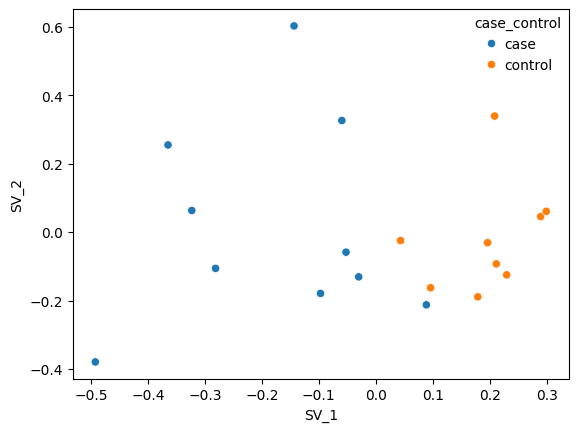

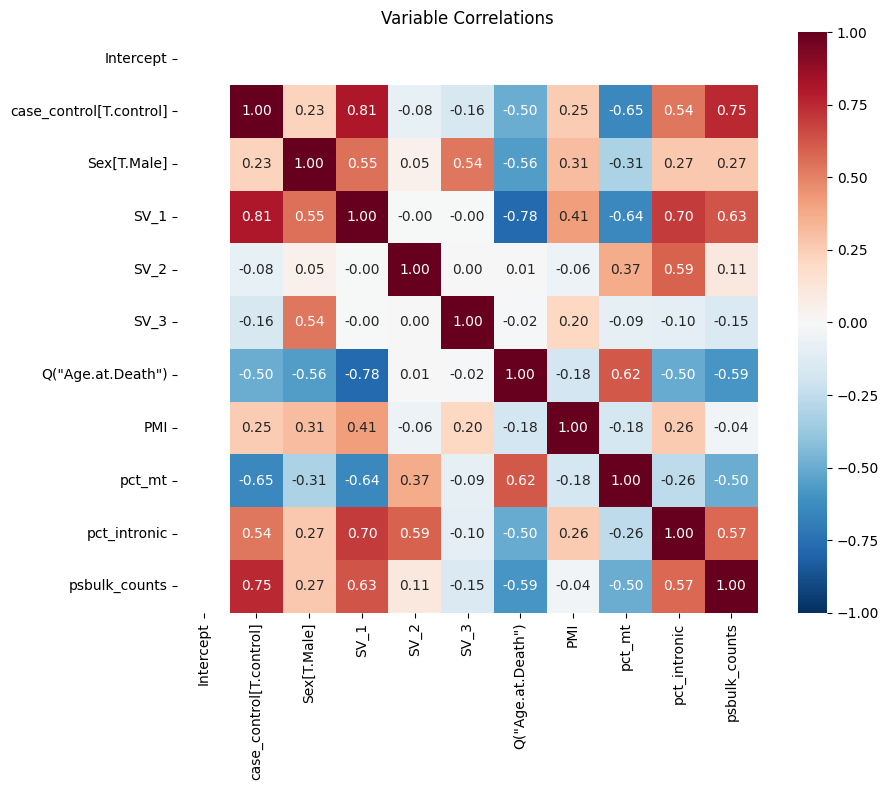

                   variable          VIF
0                 Intercept  2221.123121
3                      SV_1    24.202859
9              pct_intronic    10.785844
1   case_control[T.control]    10.668762
6         Q("Age.at.Death")     5.945428
4                      SV_2     5.231893
10            psbulk_counts     4.859687
2               Sex[T.Male]     3.847202
8                    pct_mt     3.436560
5                      SV_3     2.048794
7                       PMI     1.626384

binary identifiability test. False


In [4]:
adata_pb = sc.read_h5ad(dataset_path_h5ad)
import seaborn as sns
sns.scatterplot(adata_pb.obs, x="SV_1", y="SV_2", hue=CONTRAST_VARIABLE)
    
SVs = [cov for cov in adata_pb.obs.columns if "SV_" in cov]
DEG.check_corr_cov_in_design(adata_pb, vars_in_formula=[CONTRAST_VARIABLE, *SVs, *COVARIATES_FOR_DEG, "psbulk_counts"], corr_thr=0.7, split=" + ")


# Psudobulk DEG

In [5]:
for dataset in sorted(os.listdir(DATASET_FOLDER)):

    print(f"\n######\n Processing dataset: {GENESET} {dataset} \n######\n")

    # 2 differt saving folders
    results_folder_deseq2 = os.path.join(DATASET_FOLDER, dataset, DESEQ2_NAME)
    save_csv_path_deseq2 = os.path.join(results_folder_deseq2, f"{dataset}-{DESEQ2_NAME}_results.csv")
    results_folder_edgeR = os.path.join(DATASET_FOLDER, dataset, EDGER_NAME)
    save_csv_path_edgeR = os.path.join(results_folder_edgeR, f"{dataset}-{EDGER_NAME}_results.csv")

    # same  initial adata
    dataset_path_h5ad = os.path.join(DATASET_FOLDER, dataset, f"{dataset}_pseudobulked.h5ad")
    results_folder =results_folder_deseq2 # ny defult save in desseq


    # Read file
    adata_psuedo = sc.read_h5ad(dataset_path_h5ad)

    # Add SVs as cov
    SVs = [cov for cov in adata_psuedo.obs.columns if "SV_" in cov]
    FULL_MODEL_WITH_SVS = FULL_MODEL + " + " + " + ".join(SVs)
    print(FULL_MODEL_WITH_SVS)

    # Run psuedobulk
    try:
        original_show = plt.show

        df_merged, res_df_edgeR, res_df_pds2 = DEG.DEG_deseq2_edgeR(
            adata_pb_all=adata_psuedo,
            psuedobulk_group_for_deg=None, # do not subset
            psuedobulk_group_for_deg_col=None, # do not subset
            design_formula=FULL_MODEL_WITH_SVS, # ATTENTION to add SVs
            save_folder=results_folder,
            SAMPLE_VARIABLE=SAMPLE_VARIABLE,
            CONTRAST_VARIABLE=CONTRAST_VARIABLE,
            MIN_CELLS_PER_PSUDOCELL=MIN_CELLS_PER_PSUDOCELL,
            MIN_COUNTS_PER_PSEUDOCELL=MIN_COUNTS_PER_PSEUDOCELL,
            MIN_PSEUDOCELL_PER_GROUP=MIN_PSEUDOCELL_PER_GROUP,
            MIN_COUNTS=MIN_COUNTS,
            LARGE_N=LARGE_N,
            MIN_TOTAL_COUNTS=MIN_TOTAL_COUNTS,
            MIN_PROP_BY_EXPR=MIN_PROP_BY_EXPR,
            MIN_PROP_BY_PROP=MIN_PROP_BY_PROP,
            MIN_SMPLS=MIN_SMPLS,
            CONTRAST_BASELINE=CONTRAST_BASELINE,
            CONTRAST_STIM=CONTRAST_STIM,
            ALPHA_MULTIPLE_TEST=ALPHA_MULTIPLE_TEST,
            LOGFC_THR=LOGFC_THR,
            PVAL_THR=PVAL_THR,
            N_TOP_GENES_TO_NAME=N_TOP_GENES_TO_NAME,
            GENE_COL_NAME=GENE_COL_NAME,
            LOGFC_COL_NAME=LOGFC_COL_NAME,
            ADJ_P_VAL_COL_NAME=ADJ_P_VAL_COL_NAME,
            P_VAL_COL_NAME=P_VAL_COL_NAME, # Rename p.val col
            calculate_umap=False
        )

        res_df_edgeR.to_csv(save_csv_path_edgeR, index=False)
        res_df_pds2.to_csv(save_csv_path_deseq2, index=False)


    finally:
        plt.show = original_show

    #break

    


######
 Processing dataset: 004 depleted_0.00_dorsal_matrix 
######

~ case_control + Age.at.Death + Sex + PMI + pct_mt + pct_intronic + SV_1 + SV_2 + SV_3 + SV_4

            #########################
            ### Processing psudobulk group: None
            #########################
            

Corrected dsign Matrix: ~ case_control + Age.at.Death + Sex + PMI + pct_mt + pct_intronic + SV_1 + SV_2 + SV_3 + SV_4
Samples per group: {'case': np.int64(10), 'control': np.int64(9)}

Design formula: ~ case_control + Age.at.Death + Sex + PMI + pct_mt + pct_intronic + SV_1 + SV_2 + SV_3 + SV_4



/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "pct_ribosomal". Fall back to string conversion. The error is: Converting pandas "Category" series to R factor is only possible when categories are strings.
  warnings.warn('Error while trying to convert '
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "Neighborhood_bootstrapping_probability". Fall back to string conversion. The error is: Converting pandas "Category" series to R factor is only possible when categories are strings.
  warnings.warn('Error while trying to convert '
2026-02-11 13:31:03 | [WARNING] R callback write-console: In addition:   
2026-02-11 13:31:03 | [WARNING] R callback write-console: Warning messages:
  
2026-02-11 13:31:03 | [WARNING] R callback write-console: 1:   
2026-02-11 13:31:03 | [WARNING] R callback write

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/pydeseq2/utils.py:378: RuntimeWarning: overflow encountered in exp
  mu_ = np.maximum(size_factors * np.exp(X @ beta), min_mu)
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/pydeseq2/utils.py:230: RuntimeWarning: invalid value encountered in subtract
  -logbinom
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/pydeseq2/utils.py:382: RuntimeWarning: overflow encountered in exp
  mu_ = np.maximum(size_factors * np.exp(X @ beta), min_mu)
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/pydeseq2/utils.py:385: RuntimeWarning: invalid value encountered in divide
  + ((1 / disp + counts) * mu_ / (1 / disp + mu_)) @ X
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/pydeseq2/utils.py:378: RuntimeWarning: overflow encountered in exp
  mu_ = np.maximum(size_factors * np.exp(X @ beta), min_mu)
/home/gdallagl/myworkdir/XDP/

Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG       1345.032882       -0.174893  0.083586 -2.092362  0.036406  0.999839
A1BG-AS1   4047.644825       -0.040740  0.115935 -0.351408  0.725282  0.999839
A2M         436.748052        0.449272  0.301970  1.487804  0.136802  0.999839
A2M-AS1     706.401312        0.097926  0.153388  0.638419  0.523201  0.999839
A2ML1       531.991986       -0.014245  0.144935 -0.098288  0.921704  0.999839
...                ...             ...       ...       ...       ...       ...
ZXDC      21818.848639        0.007501  0.068030  0.110258  0.912205  0.999839
ZYG11B    16860.630069        0.030652  0.061174  0.501058  0.616330  0.999839
ZYX        3772.255909        0.035027  0.135138  0.259194  0.795485  0.999839
ZZEF1     26549.565671       -0.040719  0.046921 -0.867822  0.385492  0.999839
ZZZ3      47769.792835        

...

Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.  0.  0.  0.  0.  0.  0.  0.  0.]
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG        788.899925       -0.019110  0.152148 -0.125603  0.900046  0.969691
A1BG-AS1   2166.468391       -0.130711  0.187997 -0.695284  0.486878  0.788851
A2M         269.778372        0.914288  0.528551  1.729801  0.083666       NaN
A2M-AS1     391.293505        0.376582  0.230398  1.634482  0.102158       NaN
A2ML1       284.589950       -0.363105  0.259197 -1.400880  0.161250       NaN
...                ...             ...       ...       ...       ...       ...
ZXDC      11597.464070       -0.163875  0.119187 -1.374939  0.169150  0.519768
ZYG11B     9237.382234        0.022874  0.118202  0.193517  0.846554  0.950947
ZYX        2178.297858        0.031424  0.231405  0.135795  0.891983  0.967563
ZZEF1     14059.896579       -0.083431  0.086394 -0.965704  0.334192  0.686897
ZZZ3      25937.338311        0.26

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "pct_ribosomal". Fall back to string conversion. The error is: Converting pandas "Category" series to R factor is only possible when categories are strings.
  warnings.warn('Error while trying to convert '
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "Neighborhood_bootstrapping_probability". Fall back to string conversion. The error is: Converting pandas "Category" series to R factor is only possible when categories are strings.
  warnings.warn('Error while trying to convert '
2026-02-11 13:35:34 | [WARNING] R callback write-console: In addition:   
2026-02-11 13:35:34 | [WARNING] R callback write-console: Warning messages:
  
2026-02-11 13:35:34 | [WARNING] R callback write-console: 1:   
2026-02-11 13:35:34 | [WARNING] R callback write

Using None as control genes, passed at DeseqDataSet initialization


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/pydeseq2/utils.py:232: RuntimeWarning: invalid value encountered in multiply
  - counts * np.log(mu)
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/pydeseq2/utils.py:232: RuntimeWarning: invalid value encountered in multiply
  - counts * np.log(mu)
Fitting dispersions...
... done in 2.20 seconds.

Fitting dispersion trend curve...
... done in 0.53 seconds.

Fitting MAP dispersions...
... done in 1.84 seconds.

Fitting LFCs...
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/pydeseq2/utils.py:232: RuntimeWarning: invalid value encountered in multiply
  - counts * np.log(mu)
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/pydeseq2/utils.py:232: RuntimeWarning: invalid value encountered in multiply
  - counts * np.log(mu)
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/pydeseq2/utils.py:385: RuntimeWarning: overflow encountered in multiply
  + ((1 / disp + counts

Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.  0.  0.  0.  0.  0.  0.  0.  0.]
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG        640.584077        0.049423  0.173927  0.284159  0.776289  0.937345
A1BG-AS1   1735.894195       -0.172446  0.197313 -0.873974  0.382133  0.757433
A2M         220.802761        0.887780  0.545599  1.627165  0.103702  0.467528
A2M-AS1     311.111747        0.419830  0.257274  1.631840  0.102713  0.465777
A2ML1       228.088547       -0.413296  0.279286 -1.479835  0.138917  0.521813
...                ...             ...       ...       ...       ...       ...
ZXDC       9283.721885       -0.168618  0.127894 -1.318418  0.187364  0.584895
ZYG11B     7499.771038        0.038283  0.130706  0.292896  0.769601  0.935705
ZYX        1797.389494        0.072828  0.248064  0.293587  0.769074  0.935485
ZZEF1     11263.692595       -0.073067  0.098420 -0.742399  0.457846  0.800372
ZZZ3      20697.487034        0.26

In [6]:
res_df_pds2

,gene,baseMean,logFC_case_controlcase,lfcSE,stat,p_case_controlcase,adj_p_case_controlcase,contrast,method,is_significant
179,TESPA1,8241.764021,-4.331274,1.115286,-3.883556,0.000103,0.009822,None,Deseq2,True
5276,LINC02822,25298.803701,-4.282766,3.154984,-1.357460,0.174635,0.568714,None,Deseq2,False
592,ENSG00000287923,11886.558909,-4.261599,1.429031,-2.982160,0.002862,0.082852,None,Deseq2,False
3016,ENSG00000286269,733.455981,-4.180512,2.304723,-1.813890,0.069695,0.396985,None,Deseq2,False
1017,ENSG00000286780,9836.213458,-4.124738,1.580771,-2.609320,0.009072,0.153028,None,Deseq2,False
...,...,...,...,...,...,...,...,...,...,...
175,ENSG00000287400,133.209771,3.615972,0.921802,3.922721,0.000088,0.008549,None,Deseq2,True
6480,APOE,357.751399,3.884089,3.331240,1.165959,0.243631,0.645941,None,Deseq2,False
2238,CST3,798.214656,4.381391,2.140807,2.046607,0.040697,0.312206,None,Deseq2,False
9725,ENSG00000273295,225.903542,4.888475,6.493018,0.752882,0.451521,0.797658,None,Deseq2,False


# Plot Results

In [7]:
df_true_degs = pd.read_csv(TRUE_DEG_PATH)
df_true_degs


,gene_id,log2fc,frac_applied,n_subjects_applied,subjects_applied
0,RAB29,1.788889,0.7,7,"MD6927,MD9129,MS706984,MS876075,MS986638,UMBEB..."
1,SHCBP1,-0.944444,0.7,7,"MD9129,MS30499,MS706984,MS876075,MS986638,UMBE..."
2,INO80C,1.155556,0.7,7,"MD6927,MD9129,MS30499,MS986638,UMBEB22074,UMBE..."
3,ENSG00000234185,0.522222,0.3,3,"MD9129,MS706984,MS876075"
4,PPIH,-1.155556,0.4,4,"MS706984,MS986638,UMBEB23158,UMBEB24013"
...,...,...,...,...,...
395,ZNF780A,-0.944444,0.6,6,"MS30499,MS706984,UMBEB22074,UMBEB23076,UMBEB23..."
396,NBEA,-0.944444,0.8,8,"MD6927,MD9129,MS30499,MS876075,MS986638,UMBEB2..."
397,EPB41L1-AS1,0.733333,0.4,4,"MD9129,UMBEB23076,UMBEB23158,UMBEB24013"
398,TCTE1,-1.788889,1.0,10,"MD6927,MD9129,MS30499,MS706984,MS876075,MS9866..."



######
 Processing dataset: depleted_0.00_dorsal_matrix 
######



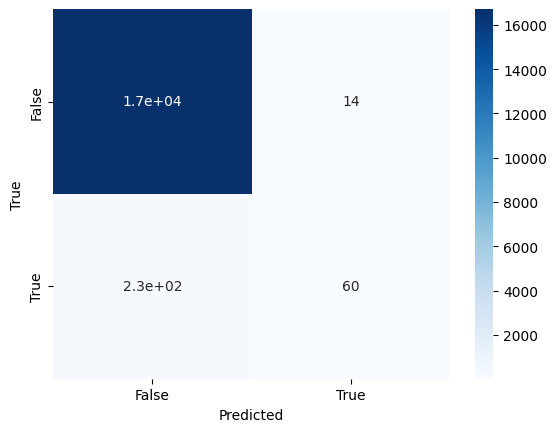

Precision: 0.811
Recall:    0.205
F1 Score:  0.328
Accuracy:  0.986
Clipping 24 genes with -log10(p) > 10


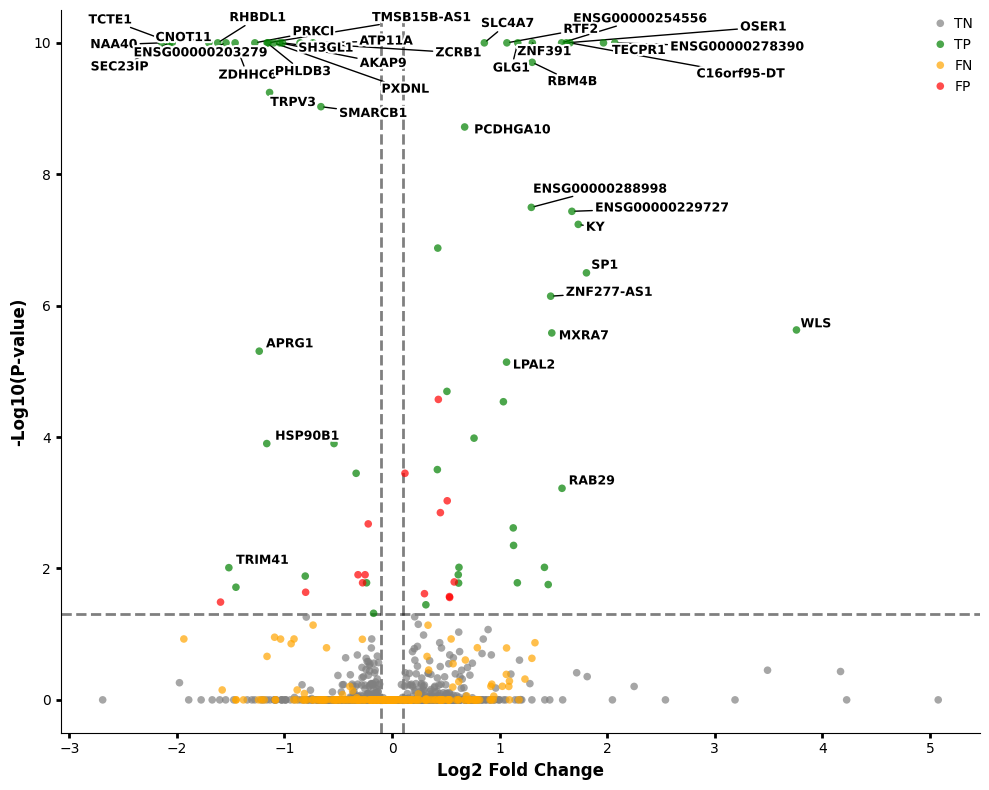

,gene,logFC_case_controlcase,p_case_controlcase,adj_p_case_controlcase,is_significant,is_true_DEG,-log10p,category,sorter
0,MCOLN3,-2.690031,2.118140e-01,9.998388e-01,False,False,0.000070,TN,-0.000188
1,NAA40,-2.139937,2.970280e-214,1.685337e-210,True,True,10.000000,TP,-21.399374
2,SEC23IP,-2.069151,3.267001e-275,5.561088e-271,True,True,10.000000,TP,-20.691511
3,TCTE1,-2.044255,1.278938e-61,2.418899e-58,True,True,10.000000,TP,-20.442546
4,CFAP95,-1.976205,5.378472e-03,5.482177e-01,False,False,0.261047,TN,-0.515882
...,...,...,...,...,...,...,...,...,...
17017,ENSG00000236209,3.490504,2.805148e-03,3.536981e-01,False,False,0.451367,TN,1.575500
17018,WLS,3.759390,4.818327e-09,2.343359e-06,True,True,5.630161,TP,21.165971
17019,THNSL2,4.169103,2.978398e-03,3.700605e-01,False,False,0.431727,TN,1.799915
17020,HCG24,4.226002,2.788599e-02,9.998388e-01,False,False,0.000070,TN,0.000296


In [8]:
for dataset in sorted(os.listdir(DATASET_FOLDER)):

    print(f"\n######\n Processing dataset: {dataset} \n######\n")

    results_folder = os.path.join(DATASET_FOLDER, dataset, DESEQ2_NAME)
    save_csv_path = os.path.join(results_folder, f"{dataset}-{DESEQ2_NAME}_results.csv")

    df_nebula = pd.read_csv(save_csv_path)

    DEG.plot_nebula_results(df_nebula, 
                    df_true_degs, 
                    col_p=f"p_{CONTRAST_VARIABLE}{CONTRAST_STIM}", 
                    col_logFC=f"logFC_{CONTRAST_VARIABLE}{CONTRAST_STIM}", 
                    col_gene="gene",
                    PVAL_THR=PVAL_THR,
                    LOGFC_THR=LOGFC_THR,
                    max_FDR=10,
                    add_adj_p_col=True
                    )
    break